## Plotting aligned parcellation maps across atlases

In [1]:
import os, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from py_util_dx.py_utils import setProjectPath
from py_util_dx.data_utils import get_roi_vtx_from_fs32k, get_roi_pacels, get_glasser_labels
from scipy.stats import ttest_1samp
import Functional_Fusion.atlas_map as am 
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import matplotlib as mpl 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import nibabel as nib
from visualizations import plot_flatmap_labels
from nitools.cifti import surf_from_cifti
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import MDS
import matplotlib.colors as mcolors
from scipy.linalg import orthogonal_procrustes

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
projectPath, mainResultsPath = setProjectPath()
dataset_name = 'MDTB' # or Demand
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A3_bayes_parcellation', f'{dataset_name}')

In [4]:
parcellations_of_interests = ['glasser', 'schaefer100']
# roi = 'PFC' 
# roi = 'parietal' 
# roi = 'somatosensory'
roi = 'visual'
n_subjects = 24 

In [5]:
# atlas_name = 'glasser'
atlas_name = 'schaefer100'
# atlas_name = 'yeo17'
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
resultsPath = os.path.join(mainResultsPath, 'START_A4_parcellation_evaluation', f'{dataset_name}', atlas_name, 'aligned_atlas')
if not os.path.exists(resultsPath):
    os.makedirs(resultsPath)

In [6]:
example_subjIs = np.arange(n_subjects)
# example_subjIs = [5, 4]
n_example_subjects = len(example_subjIs) 
frames_dict = {
    'PFC': [[-210, 25, -90, 140], [0, 240, -110, 120]], 
    'visual': [[100, 230, -70, 160], [-250, -50, -70, 130]], 
    'somatosensory':[[-10, 80, -10, 160], [-60, 30, -10, 140]], 
    'parietal': [[20, 140, 0, 160], [-140, -30, 0, 160]]
}
gridspec_dict = {
    'PFC': [-0.2, -0.05],
    'visual': [-0.2, -0.12],
    'parietal': [-0.55, -0.25],
    'somatosensory': [-0.55, -0.05]
}

In [7]:
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

In [8]:
# first make a plot of the whole cortex 
atlas_fname = [os.path.join(surface_helpers_dir, f'{atlas_name}.L.label.gii'), os.path.join(surface_helpers_dir, f'{atlas_name}.R.label.gii')]
U = atlas.read_data(atlas_fname)

/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)
/Users/jkderrick028/Documents/Projects/7TfMRI/pfc_parcellation/code/SUITPy/flatmap.py:354: RuntimeWarning: invalid value encountered in cast
  data_arr = data_arr.astype(int)


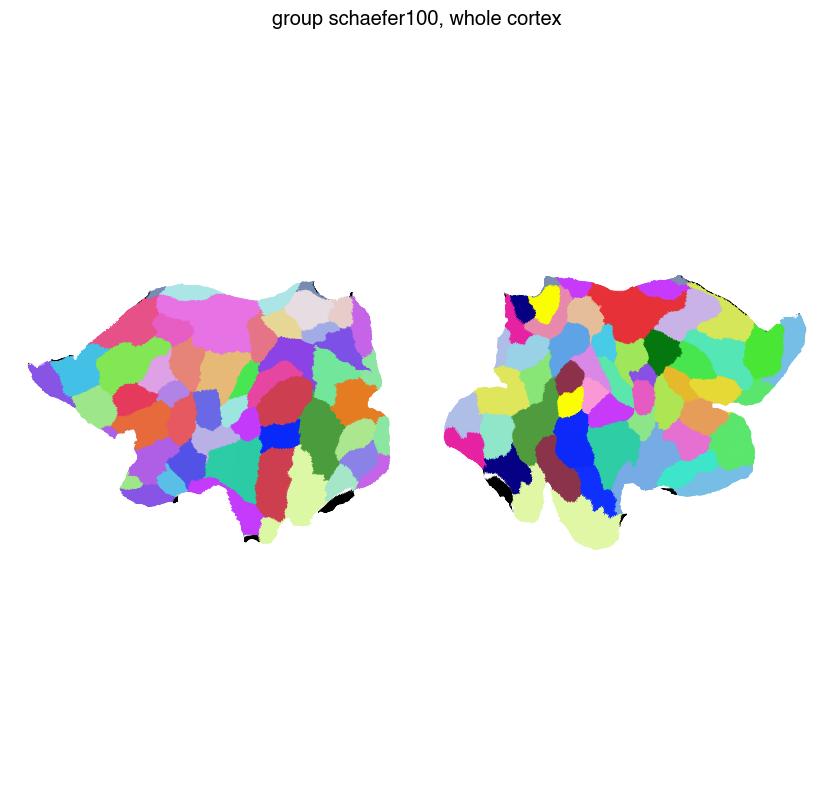

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(full_width, 8))
fig.set_figwidth(full_width)

[label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(U.reshape(1, -1)))
# lut = os.path.join(surface_helpers_dir, f'atl-{atlas_name}_original.lut')
lut = os.path.join(surface_helpers_dir, f'atl-{atlas_name}.lut')
plt.axes(ax[0])
plot_flatmap_labels(label_L, 'L', borders=None, atlas=atlas_name, lut=lut)

plt.axes(ax[1])
plot_flatmap_labels(label_R, 'R', borders=None, atlas=atlas_name, lut=lut)

plt.suptitle(f'group {atlas_name}, whole cortex')
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'{atlas_name}_group_whole_cortex_original_color.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

In [10]:
PKL_individualized_parcellation = os.path.join(projectPath, 'results', 'START_A3_bayes_parcellation', f'{dataset_name}', atlas_name, f'output_{roi}.pkl')
with open(PKL_individualized_parcellation, 'rb') as pf:
    output_indiv = pickle.load(pf)
    labels_in_group = output_indiv['labels_in_group']
    parcel_names_in_group = output_indiv['parcel_names_in_group']

    U_individual = output_indiv['U_individual']     # data only parcellation
    indiv_parcellation = output_indiv['indiv_parcellation']

    U_group = output_indiv['U_group']
    group_parcellation = output_indiv['group_parcellation']

    group_parcellation[group_parcellation==0] = np.max(group_parcellation)

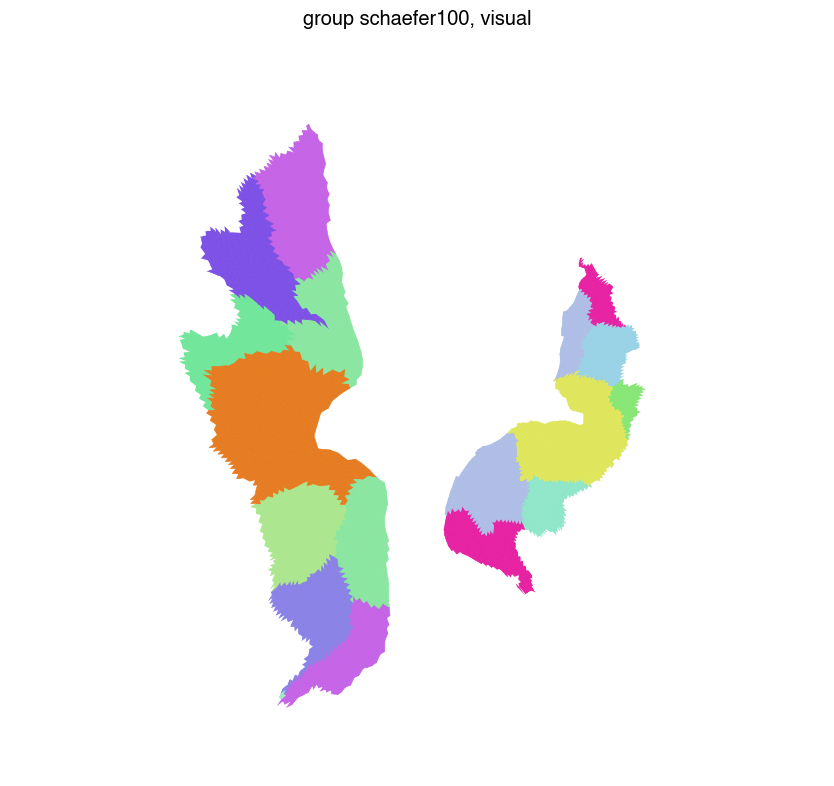

In [11]:
# plotting the group map
# fig, ax = plt.subplots(1, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
fig, ax = plt.subplots(1, 2, figsize=(full_width, 8))
fig.set_figwidth(full_width)

lut = os.path.join(surface_helpers_dir, f'atl-{atlas_name}.lut')
[label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
label_L[np.isnan(label_L)] = np.max(group_parcellation)
label_R[np.isnan(label_R)] = np.max(group_parcellation)

plt.axes(ax[0])
plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name, lut=lut)

plt.axes(ax[1])
plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name, lut=lut)

plt.suptitle(f'group {atlas_name}, {roi}')
plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'group_{atlas_name}_{roi}.jpg')
plt.savefig(JPG_fig, dpi=500, format='jpg')

In [12]:
np.unique(group_parcellation)

array([  1,   2,   3,   4,   5,   6,   7,  48,  49,  51,  52,  53,  54,
        55,  56, 101], dtype=int32)

/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59737/4266865472.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59737/4266865472.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59737/4266865472.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59737/4266865472.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x18vm0000gn/T/ipykernel_59737/4266865472.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/hv/x8n5hv816wl3ld__pv8x1

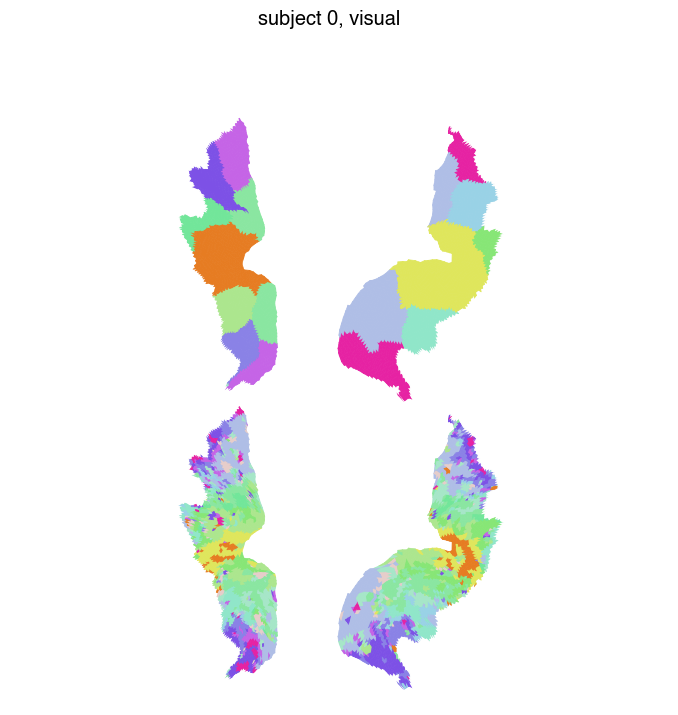

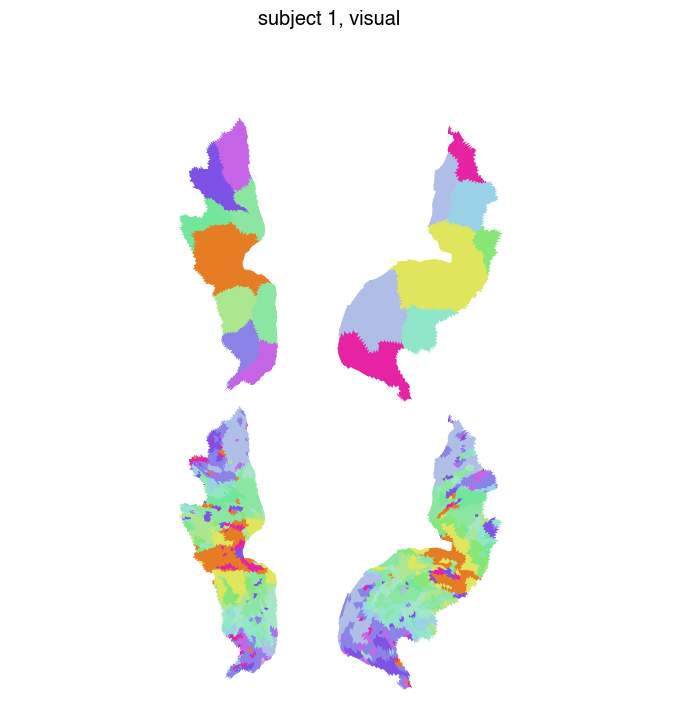

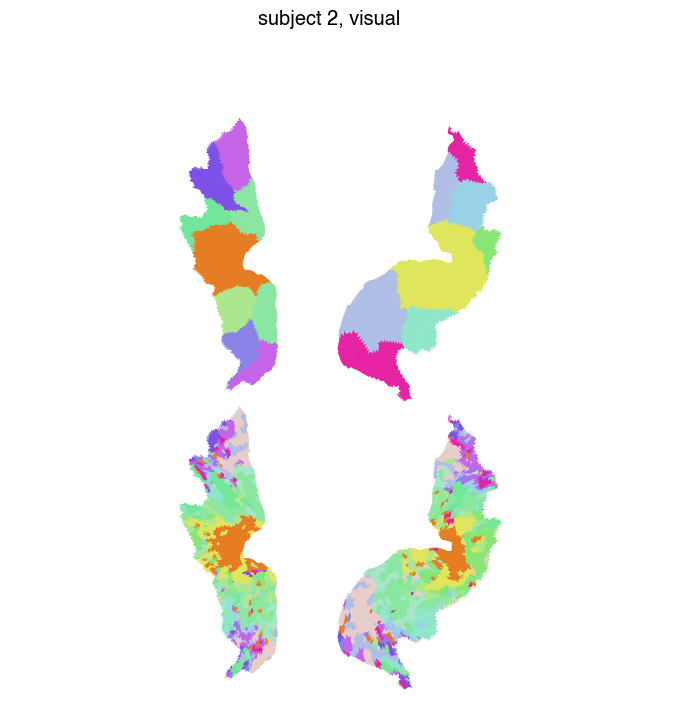

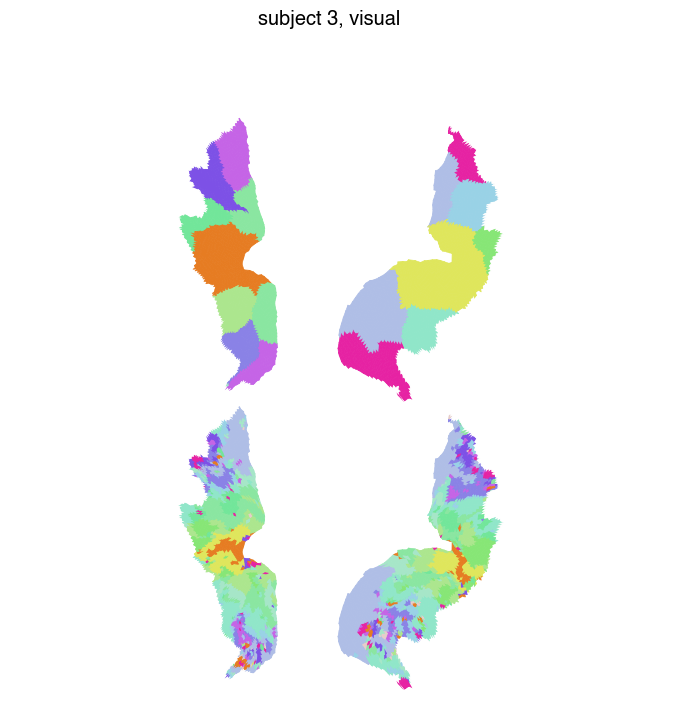

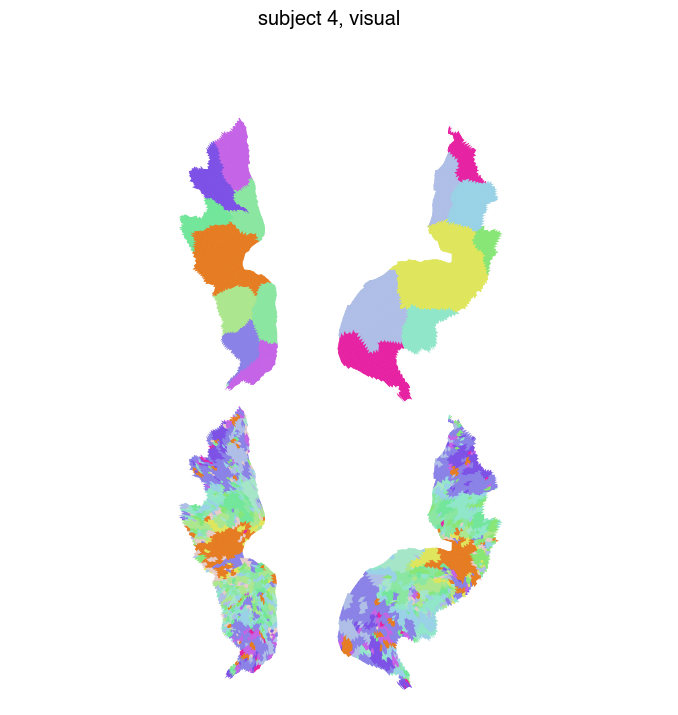

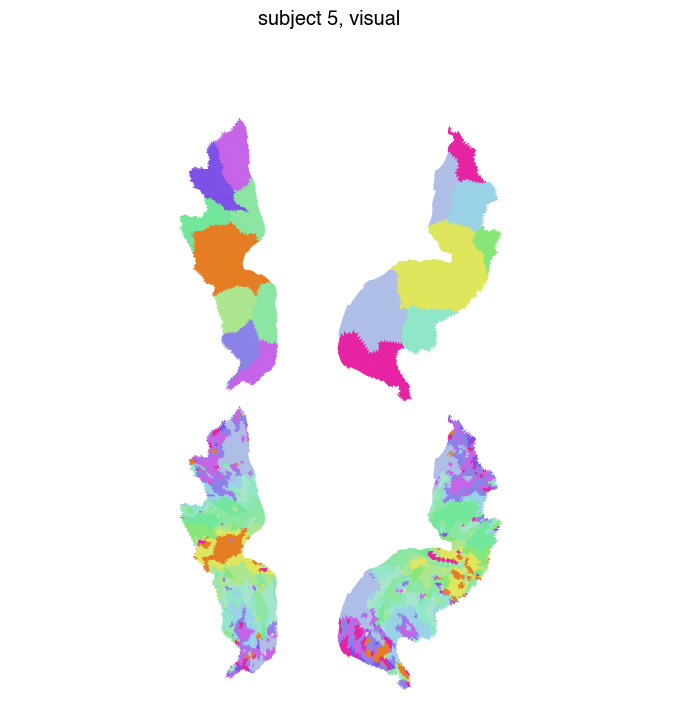

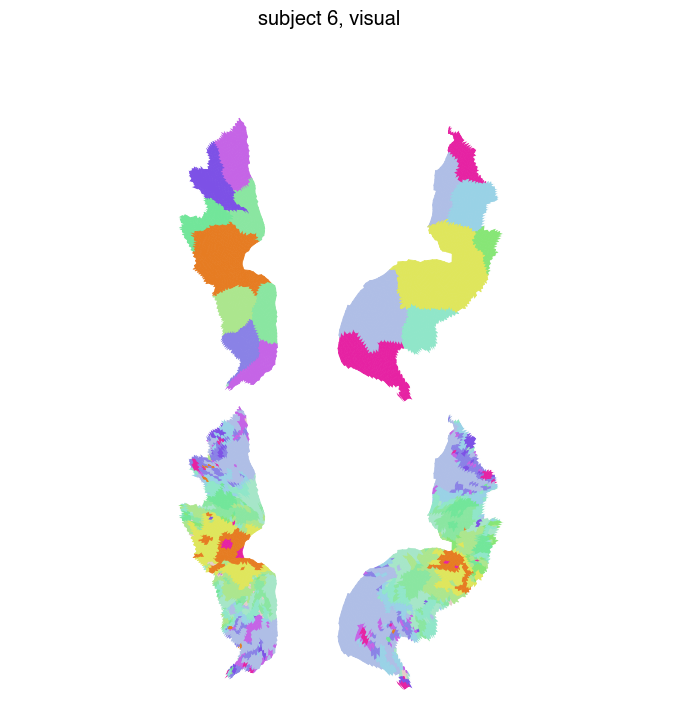

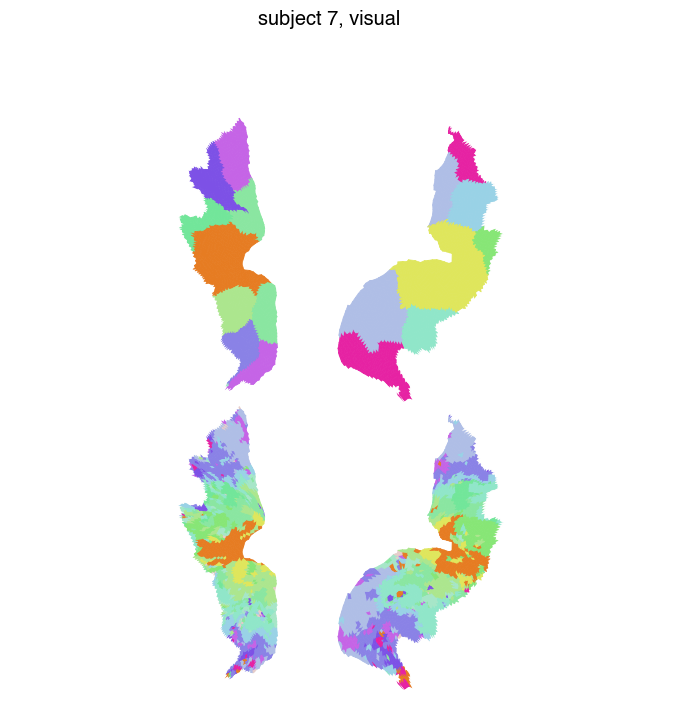

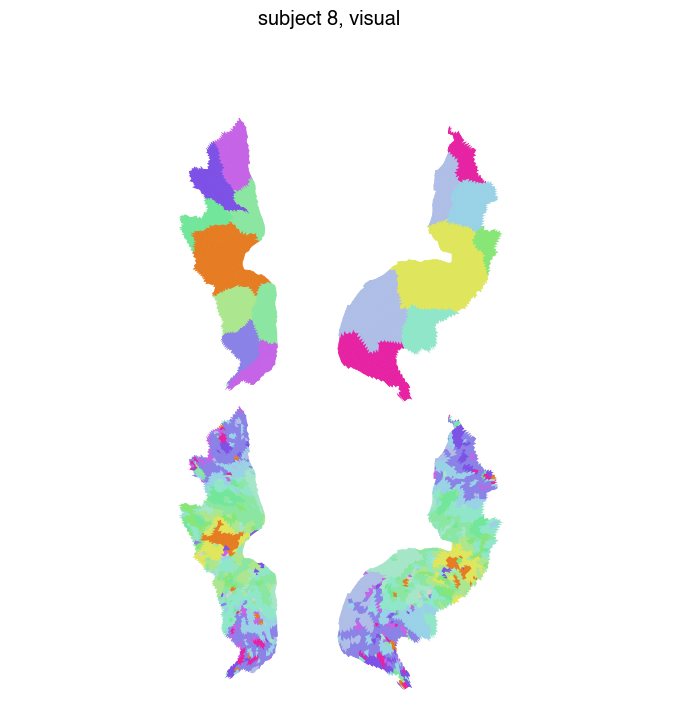

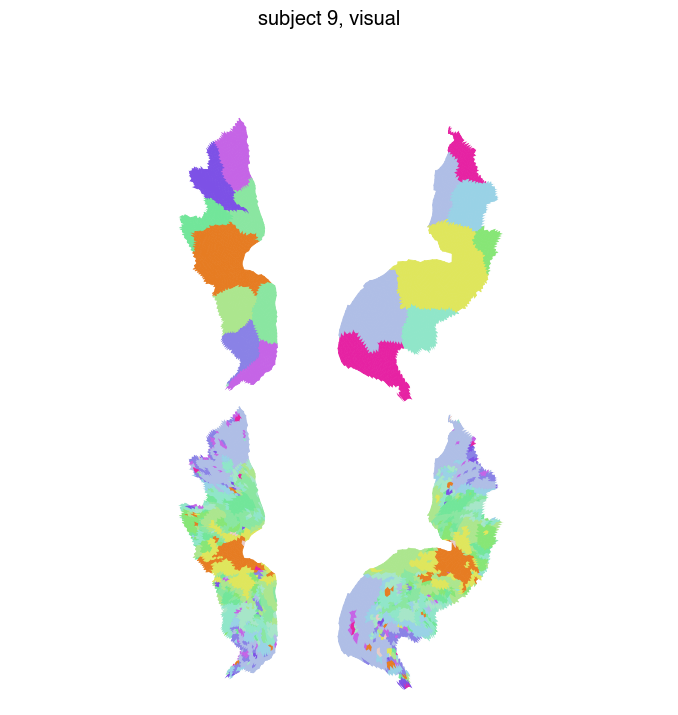

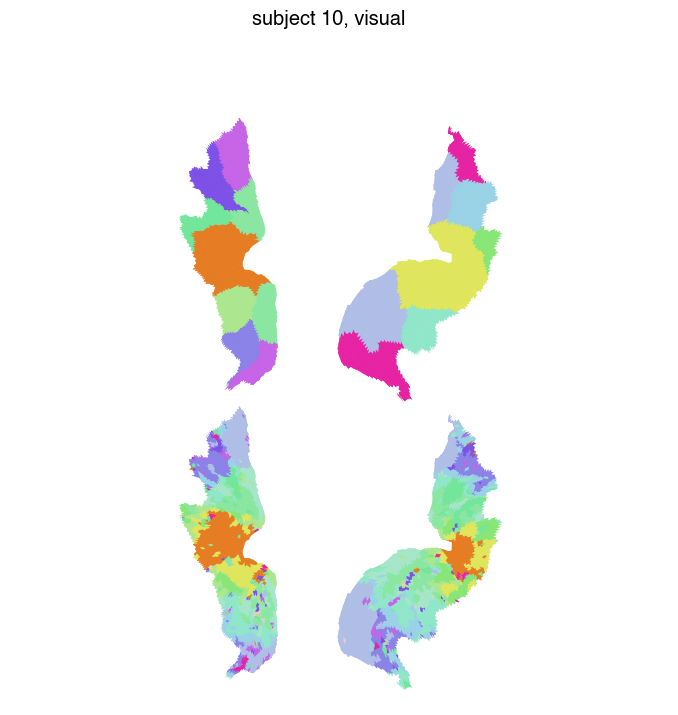

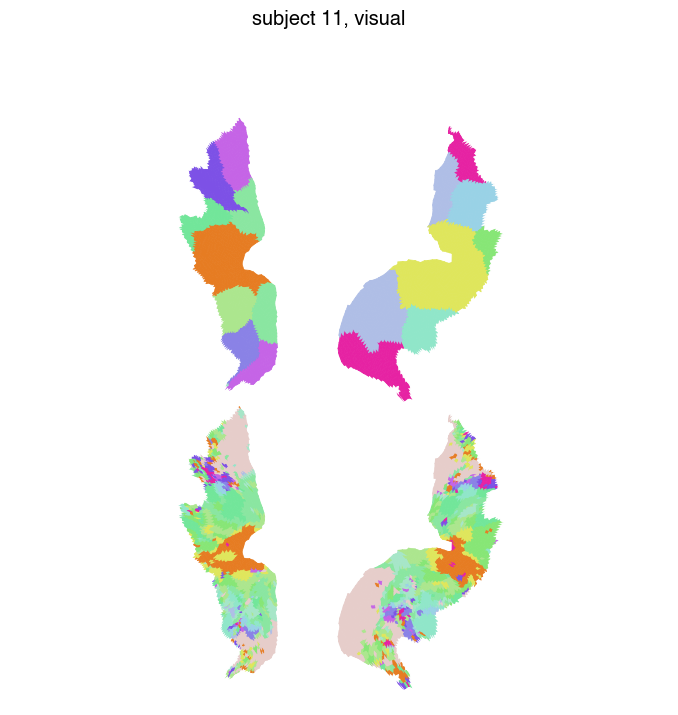

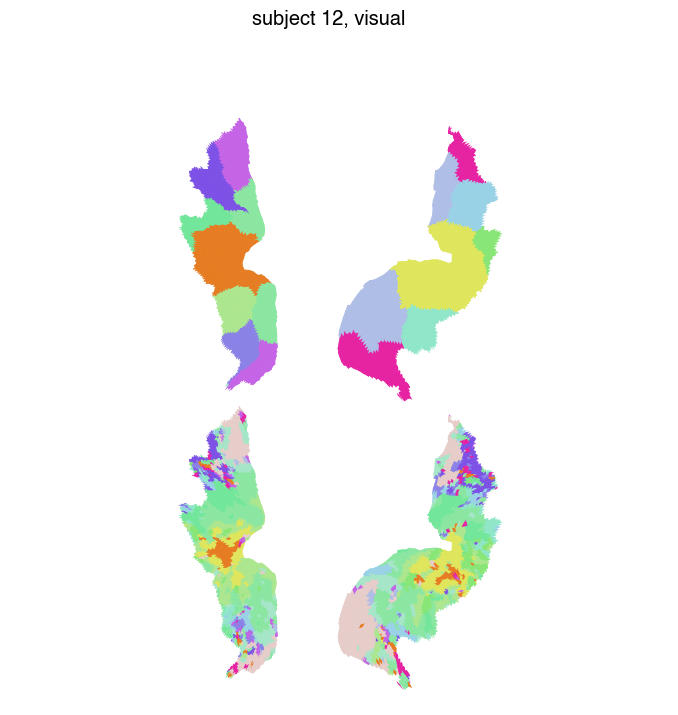

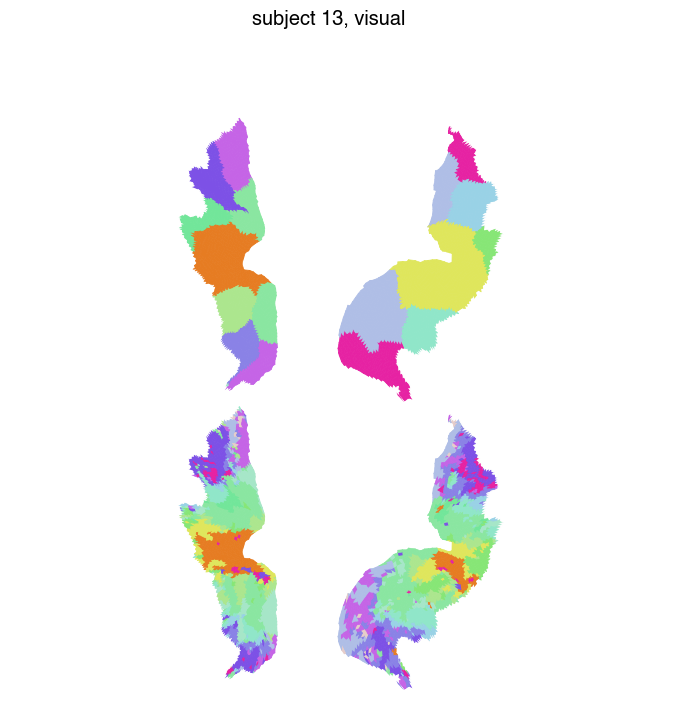

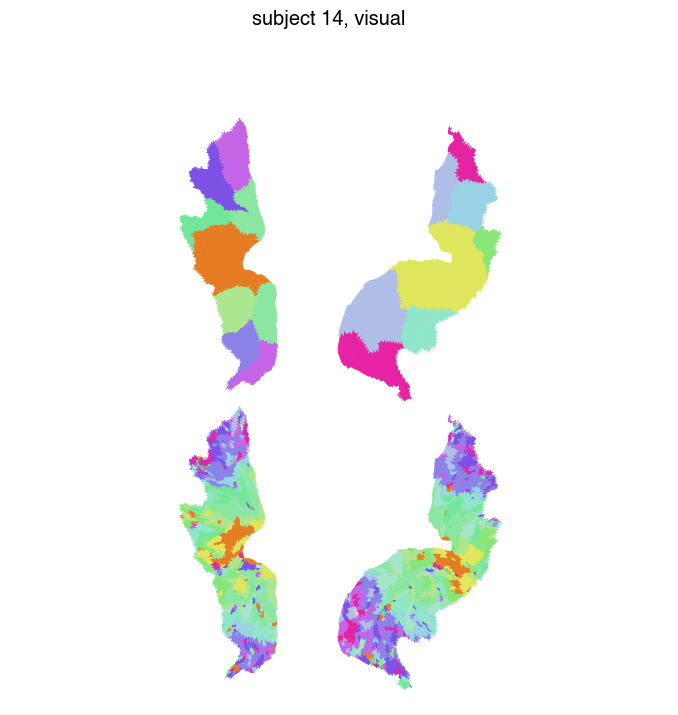

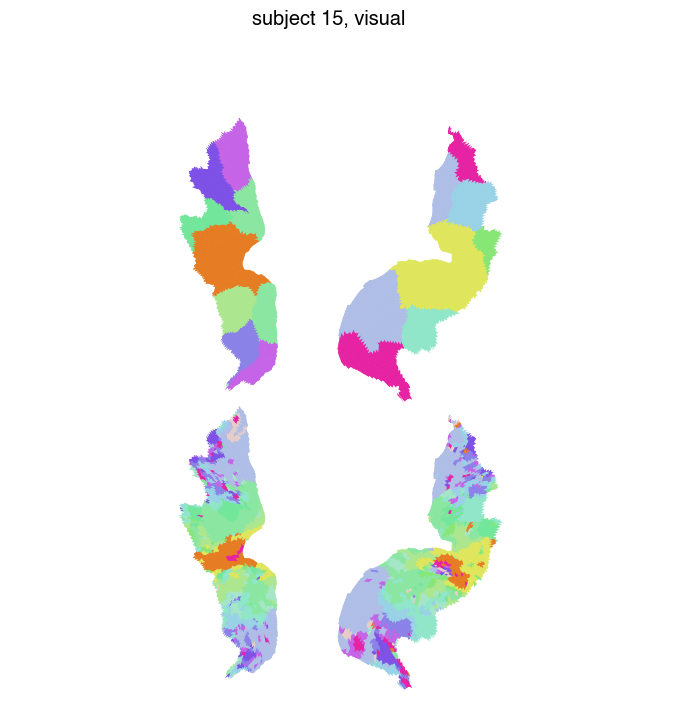

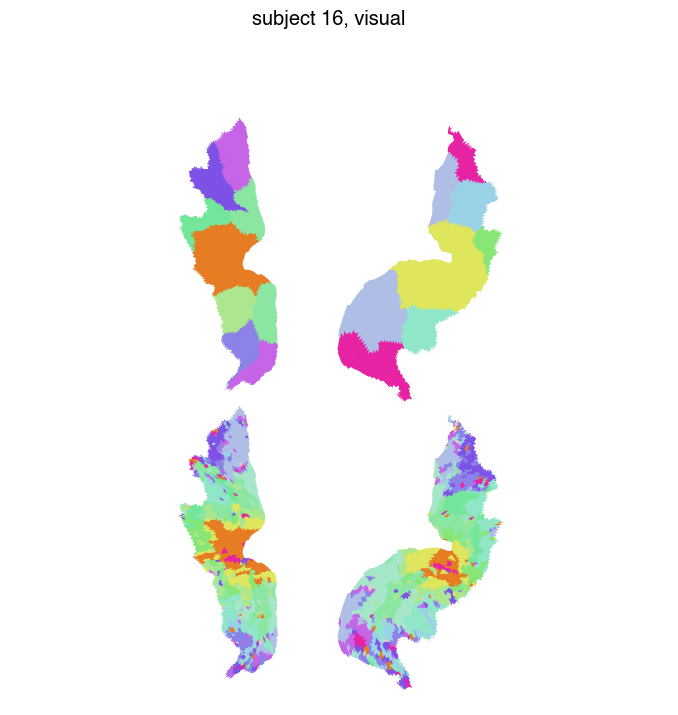

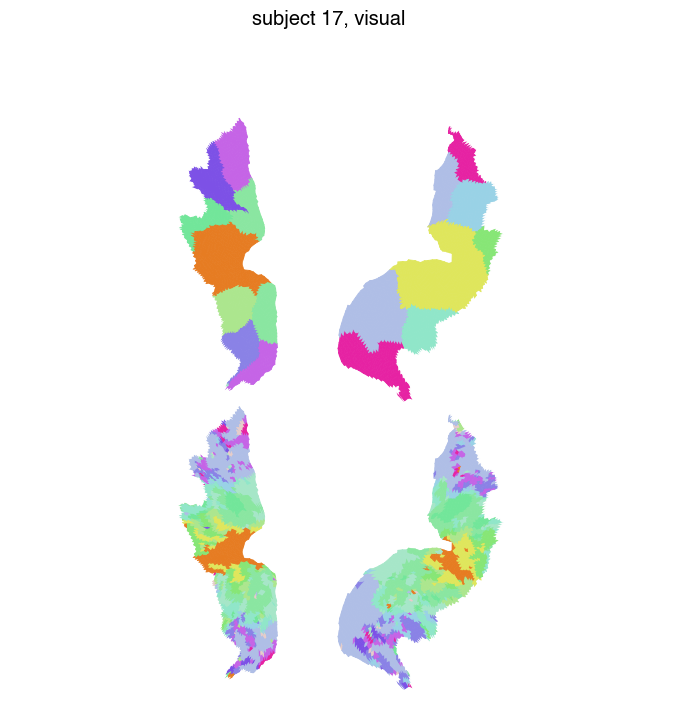

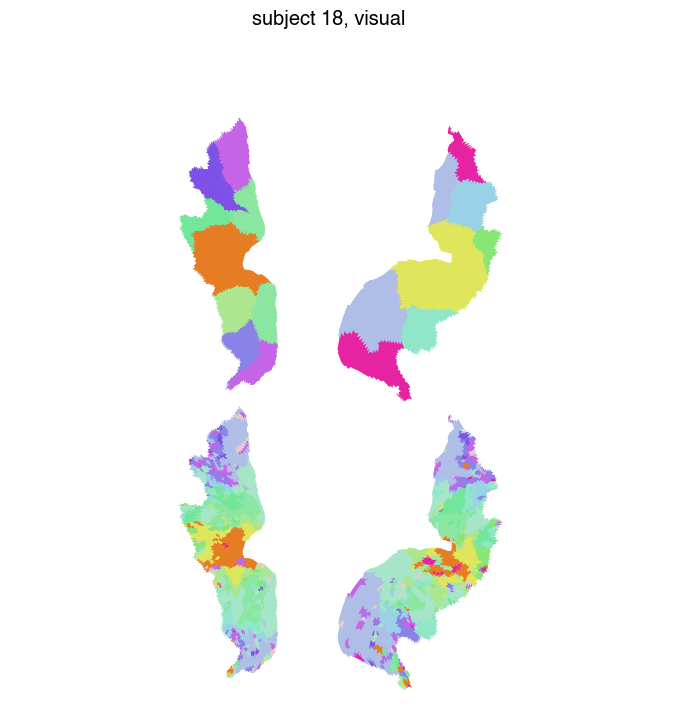

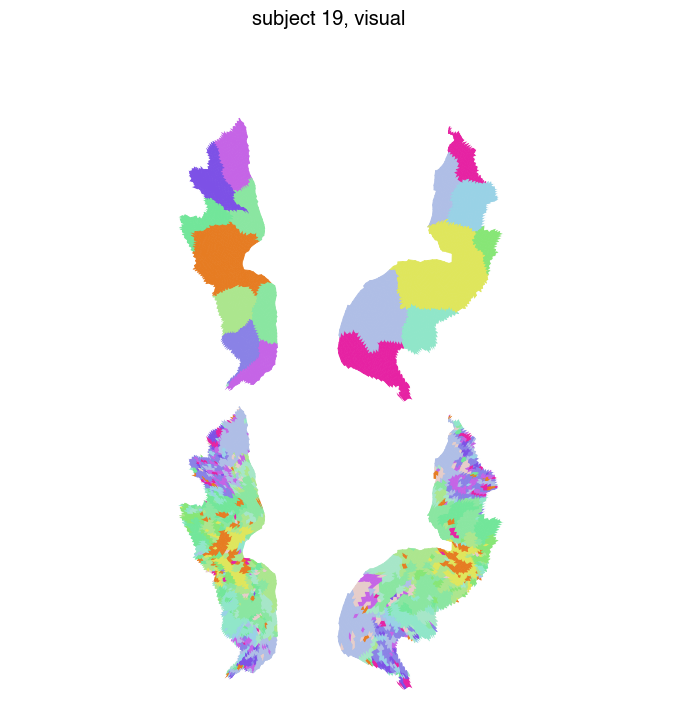

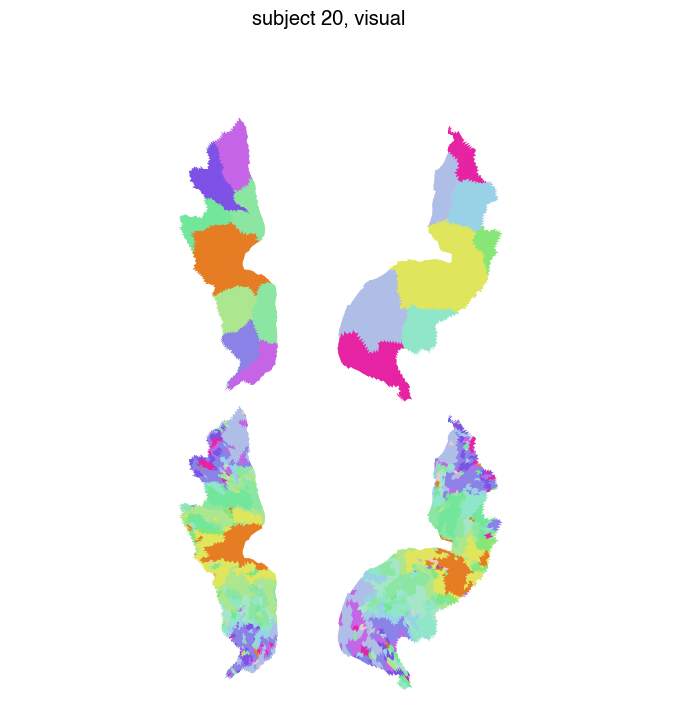

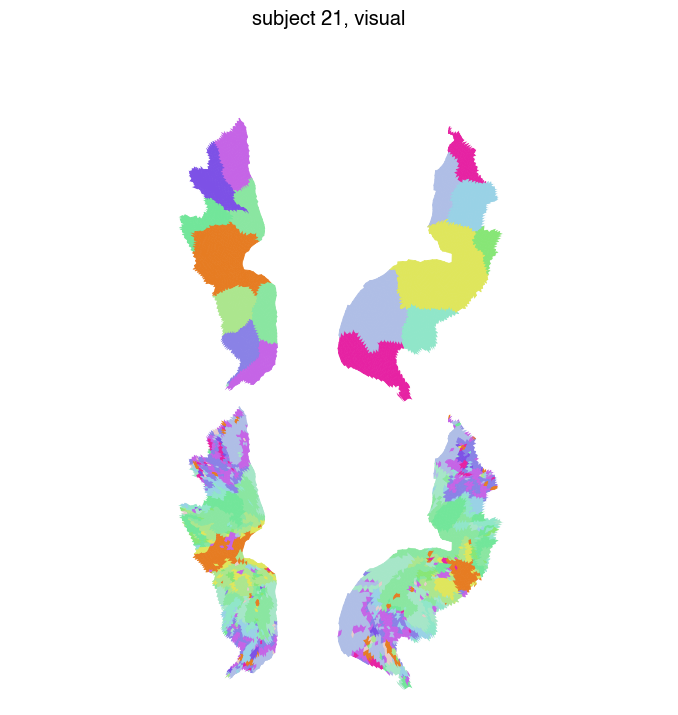

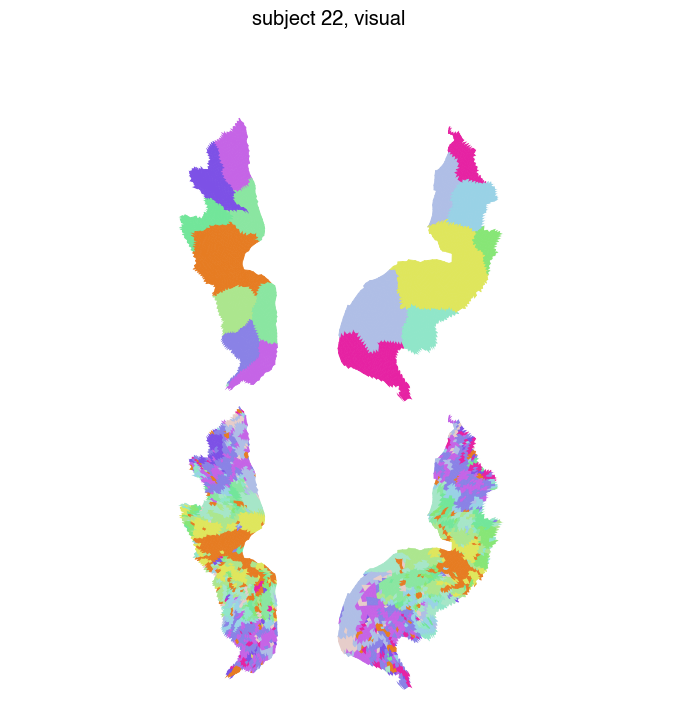

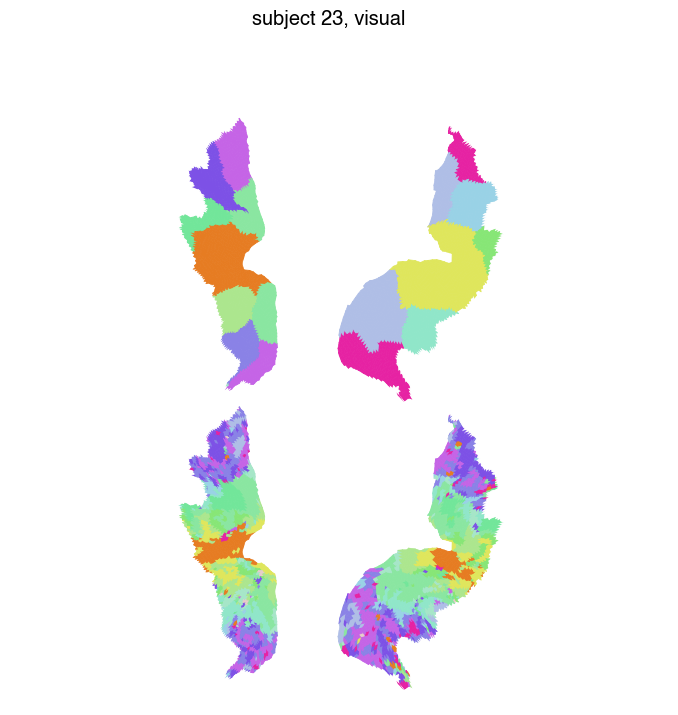

In [13]:
for subjI in example_subjIs:
    fig, ax = plt.subplots(2, 2, figsize=(full_width, 8), constrained_layout=True, gridspec_kw={'wspace': gridspec_dict[roi][0], 'hspace': gridspec_dict[roi][1]})
    fig.set_figwidth(full_width)

    lut = os.path.join(surface_helpers_dir, f'atl-{atlas_name}.lut')
    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(group_parcellation.reshape(1, -1)))
    label_L[np.isnan(label_L)] = np.max(group_parcellation)
    label_R[np.isnan(label_R)] = np.max(group_parcellation)

    plt.axes(ax[0, 0])
    plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name, lut=lut)

    plt.axes(ax[0, 1])
    plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name, lut=lut)
    
    [label_L, label_R] = surf_from_cifti(atlas.data_to_cifti(indiv_parcellation[subjI].reshape(1, -1)))
    label_L[np.isnan(label_L)] = np.max(group_parcellation)
    label_R[np.isnan(label_R)] = np.max(group_parcellation)
    
    plt.axes(ax[1, 0])
    plot_flatmap_labels(label_L, 'L', frame=frames_dict[roi][0], borders=None, atlas=atlas_name, lut=lut)
    
    plt.axes(ax[1, 1])
    plot_flatmap_labels(label_R, 'R', frame=frames_dict[roi][1], borders=None, atlas=atlas_name, lut=lut)

    plt.suptitle(f'subject {subjI}, {roi}')
    plt.tight_layout() 

    JPG_fig = os.path.join(resultsPath, f'example_{atlas_name}_{roi}_subject_{subjI}.jpg')
    plt.savefig(JPG_fig, dpi=500, format='jpg')